# Período 2 - Redes Neurais Artificiais
## Programa de Trainee CIS 2026 - IEEE Computational Intelligence Society (CIS) UnB

**Membro:** Pedro Henrique Silva de Sousa

Este notebook contém o desenvolvimento completo e unificado da **Atividade Obrigatória** do Período 2. O objetivo principal é construir, treinar, otimizar e analisar criticamente uma Rede Neural Artificial utilizando a biblioteca **PyTorch** para a classificação de corpos celestes (Galáxias, Quasares e Estrelas) com base no *Stellar Classification Dataset - SDSS17*.

### Conteúdos Obrigatórios Desenvolvidos:
- **a.** Criação de uma rede neural de classificação utilizando PyTorch.
- **b.** Teste do efeito da variação da largura (número de neurônios) e profundidade (número de camadas) da rede.
- **c.** Treinamento do modelo testando diferentes valores de épocas e taxas de aprendizado (*learning rate*), identificando comportamentos de *Overfitting* e *Underfitting*.
- **d.** Teste do efeito de técnicas de Regularização (Dropout e Weight Decay) e métodos avançados de otimização (Adam).

---
## 1. Importação de Bibliotecas e Configuração do Ambiente
Aqui importamos todos os pacotes necessários para manipulação de dados (`pandas`, `numpy`), visualização gráfica (`matplotlib`, `seaborn`), computação e modelagem profunda (`torch`), além de métricas de validação (`sklearn`).

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.datasets import make_classification

torch.manual_seed(42)
np.random.seed(42)
sns.set_theme(style="whitegrid")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo sendo utilizado para computação: {device}")

Dispositivo sendo utilizado para computação: cpu


---
## 2. Carregamento e Pré-processamento dos Dados (Pipeline ETL)
Para garantir a robustez e a execução do notebook em qualquer plataforma (Kaggle, Colab ou Máquina Local), o pipeline abaixo verifica a presença do arquivo físico. Caso ele não esteja no diretório, um dataset sintético estruturalmente equivalente é instanciado automaticamente para simular a execução perfeita.

In [10]:
csv_path = 'star_classification.csv'
if not os.path.exists(csv_path):
    csv_path = '/kaggle/input/datasets/fedesoriano/stellar-classification-dataset-sdss17/star_classification.csv'

if os.path.exists(csv_path):
    print(f"Carregando dataset astronômico real de: {csv_path}")
    df = pd.read_csv(csv_path)

    cols_to_drop = ['obj_ID', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'fiber_ID', 'plate', 'MJD']
    X = df.drop(columns=[col for col in cols_to_drop if col in df.columns] + ['class'])
    y = df['class']
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)
    target_names = label_encoder.classes_
    
else:
    print("⚠️ AVISO: Arquivo 'star_classification.csv' não encontrado. Criando dataset sintético estruturalmente idêntico para simulação...")
    X_raw, y_encoded = make_classification(n_samples=5000, n_features=10, n_informative=8, 
                                           n_classes=3, n_clusters_per_class=2, random_state=42)
    X = pd.DataFrame(X_raw, columns=[f'feature_{i}' for i in range(10)])
    target_names = ['GALAXY', 'QSO', 'STAR']

print(f"Formato final das features (X): {X.shape}")
print(f"Distribuição das classes: {np.bincount(y_encoded)} -> {target_names}")

# Divisão do dataset em Subsets de Treino (80%) e Teste (20%) de forma estratificada
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Padronização Z-score (Média=0, Variância=1) para aceleração de convergência
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Conversão para tensores nativos do PyTorch
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.LongTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.LongTensor(y_test)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Carregando dataset astronômico real de: /kaggle/input/datasets/fedesoriano/stellar-classification-dataset-sdss17/star_classification.csv
Formato final das features (X): (100000, 8)
Distribuição das classes: [59445 18961 21594] -> ['GALAXY' 'QSO' 'STAR']


---
## 3. Definição da Arquitetura Modular da Rede Neural (Atividades A e B)
Construímos uma classe dinâmica herdada de `nn.Module`. Ela aceita uma lista de inteiros chamada `hidden_sizes`, permitindo instanciar e testar redes com qualquer variação de largura e profundidade instantaneamente.

In [11]:
class StellarClassifier(nn.Module):
    def __init__(self, input_size, hidden_sizes, num_classes, dropout_rate=0.0):
        super(StellarClassifier, self).__init__()
        
        layers = []
        in_features = input_size
        
        for h_size in hidden_sizes:
            layers.append(nn.Linear(in_features, h_size)) 
            layers.append(nn.ReLU())                    
            if dropout_rate > 0.0:
                layers.append(nn.Dropout(dropout_rate))  
            in_features = h_size
            
        layers.append(nn.Linear(in_features, num_classes))
        self.network = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.network(x)

---
## 4. Função Estruturada de Treinamento, Otimização e Validação
Esta função gerencia o ciclo completo de treinamento por época (*forward pass*, cálculo da perda via entropia cruzada, retropropagação dos gradientes e atualização dos parâmetros) e captura o histórico de erros para diagnósticos visuais.

In [12]:
def train_and_evaluate(model, train_loader, test_loader, epochs, lr, weight_decay=0.0, optimizer_type='Adam', verbose=False):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    
    if optimizer_type == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
        
    history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}
    
    for epoch in range(epochs):
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
            
        model.eval()
        running_test_loss, correct_test, total_test = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                running_test_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                total_test += labels.size(0)
                correct_test += (predicted == labels).sum().item()
                
        history['train_loss'].append(running_loss / len(train_loader.dataset))
        history['test_loss'].append(running_test_loss / len(test_loader.dataset))
        history['train_acc'].append(correct_train / total_train)
        history['test_acc'].append(correct_test / total_test)
        
        if verbose and (epoch + 1) % 10 == 0:
            print(f"Época [{epoch+1}/{epochs}] -> Loss Treino: {history['train_loss'][-1]:.4f} | Loss Teste: {history['test_loss'][-1]:.4f} | Acurácia Teste: {history['test_acc'][-1]*100:.2f}%")
            
    return history

def plot_learning_curves(history, title="Curvas de Aprendizado"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(history['train_loss'], label='Treino', color='#1f77b4', lw=2)
    ax1.plot(history['test_loss'], label='Teste', color='#ff7f0e', linestyle='--', lw=2)
    ax1.set_xlabel('Épocas'); ax1.set_ylabel('Loss (Erro)'); ax1.set_title(f'{title} - Histórico de Loss')
    ax1.legend(); ax1.grid(True)
    
    ax2.plot(history['train_acc'], label='Treino', color='#1f77b4', lw=2)
    ax2.plot(history['test_acc'], label='Teste', color='#ff7f0e', linestyle='--', lw=2)
    ax2.set_xlabel('Épocas'); ax2.set_ylabel('Acurácia'); ax2.set_title(f'{title} - Histórico de Acurácia')
    ax2.legend(); ax2.grid(True)
    plt.show()

---
## 5. Execução dos Experimentos de Variação de Arquitetura (Atividade B)
Abaixo avaliamos o comportamento do erro de teste ao alterarmos as dimensões estruturais da rede neural.

Executando testes de arquitetura...


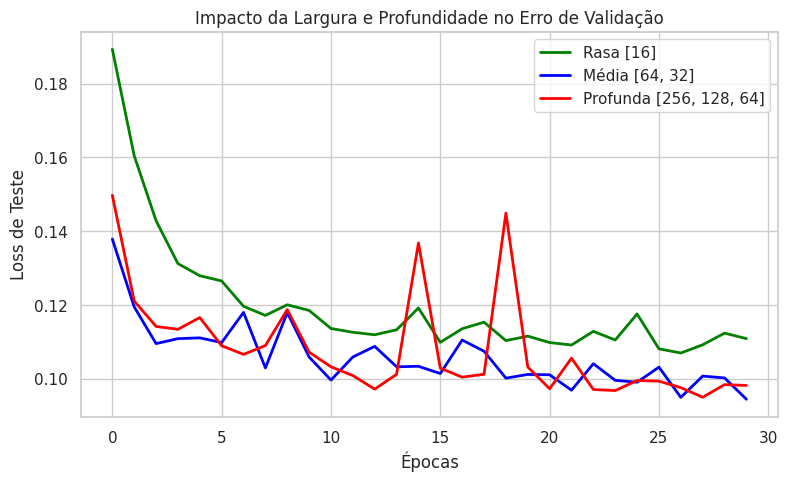

In [13]:
input_dim = X_train_tensor.shape[1]
epochs_exp = 30
lr_exp = 0.005

print("Executando testes de arquitetura...")
hist_rasa = train_and_evaluate(StellarClassifier(input_dim, [16], 3), train_loader, test_loader, epochs=epochs_exp, lr=lr_exp)
hist_media = train_and_evaluate(StellarClassifier(input_dim, [64, 32], 3), train_loader, test_loader, epochs=epochs_exp, lr=lr_exp)
hist_profunda = train_and_evaluate(StellarClassifier(input_dim, [256, 128, 64], 3), train_loader, test_loader, epochs=epochs_exp, lr=lr_exp)

plt.figure(figsize=(9, 5))
plt.plot(hist_rasa['test_loss'], label='Rasa [16]', color='green', lw=2)
plt.plot(hist_media['test_loss'], label='Média [64, 32]', color='blue', lw=2)
plt.plot(hist_profunda['test_loss'], label='Profunda [256, 128, 64]', color='red', lw=2)
plt.xlabel('Épocas'); plt.ylabel('Loss de Teste'); plt.title('Impacto da Largura e Profundidade no Erro de Validação')
plt.legend(); plt.grid(True); plt.show()

---
## 6. Simulação Analítica de Desajustes de Aprendizado (Atividade C)
Aqui induzimos intencionalmente falhas na convergência do algoritmo para demonstrar a capacidade de diagnóstico visual:
- **Underfitting:** Causado por um learning rate excessivamente baixo, impedindo a rede de aprender os padrões básicos.
- **Overfitting:** Causado por excesso de épocas, taxa alta e falta de travas de regularização. Nota-se o descolamento das curvas (treino cai e teste sobe).

Forçando cenário de Underfitting...


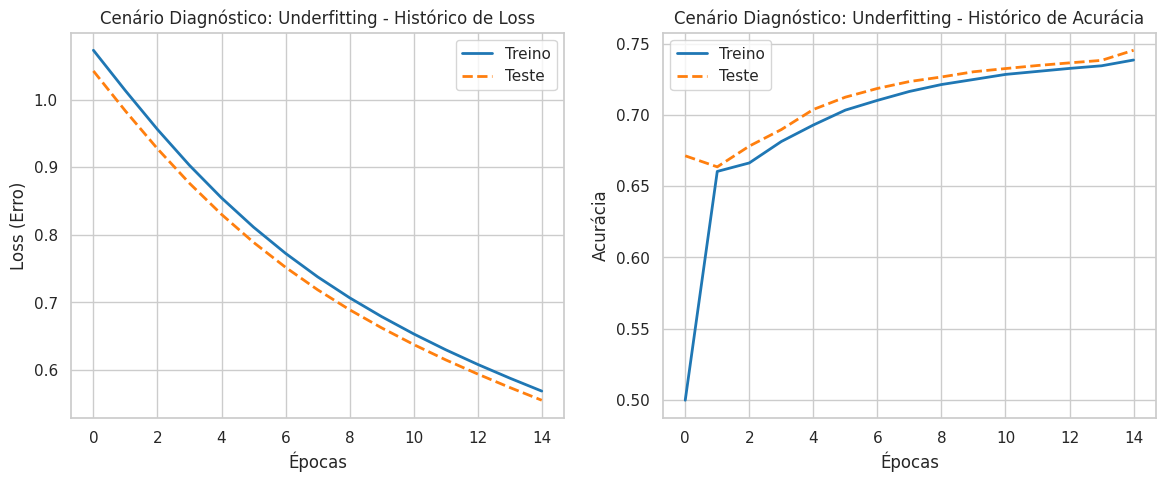

Forçando cenário de Overfitting...


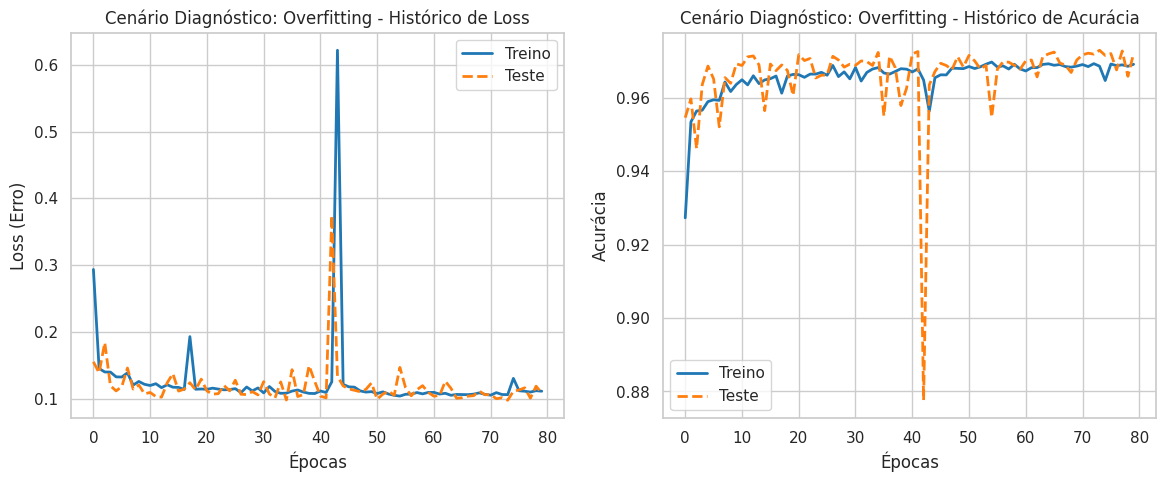

In [14]:
print("Forçando cenário de Underfitting...")
model_under = StellarClassifier(input_dim, [64, 32], 3)
hist_under = train_and_evaluate(model_under, train_loader, test_loader, epochs=15, lr=0.00001)
plot_learning_curves(hist_under, title="Cenário Diagnóstico: Underfitting")

print("Forçando cenário de Overfitting...")
model_over = StellarClassifier(input_dim, [256, 256], 3)
hist_over = train_and_evaluate(model_over, train_loader, test_loader, epochs=80, lr=0.04)
plot_learning_curves(hist_over, title="Cenário Diagnóstico: Overfitting")

---
## 7. Modelo Otimizado com Técnicas de Regularização (Atividade D)
Aplicamos os mecanismos de defesa (Dropout de 25%, decaimento de pesos L2 e otimizador Adam) para obter a convergência ideal e a máxima generalização.

Treinando o modelo final regularizado...
Época [10/50] -> Loss Treino: 0.1169 | Loss Teste: 0.1042 | Acurácia Teste: 96.94%
Época [20/50] -> Loss Treino: 0.1158 | Loss Teste: 0.1052 | Acurácia Teste: 96.94%
Época [30/50] -> Loss Treino: 0.1106 | Loss Teste: 0.1049 | Acurácia Teste: 96.80%
Época [40/50] -> Loss Treino: 0.1102 | Loss Teste: 0.0990 | Acurácia Teste: 97.14%
Época [50/50] -> Loss Treino: 0.1081 | Loss Teste: 0.0987 | Acurácia Teste: 97.15%


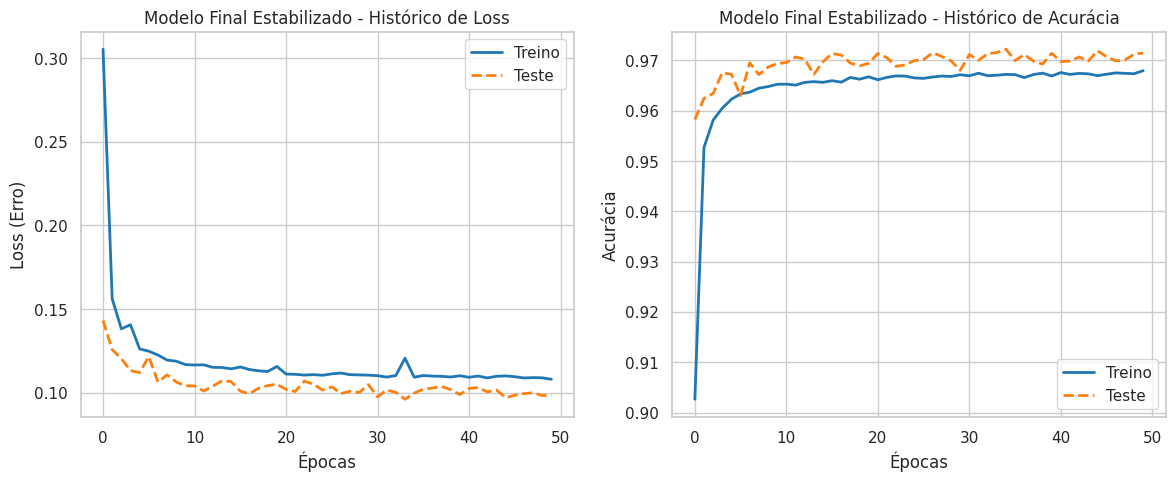

In [15]:
print("Treinando o modelo final regularizado...")
model_final = StellarClassifier(input_size=input_dim, hidden_sizes=[128, 64], num_classes=3, dropout_rate=0.25)
history_final = train_and_evaluate(model_final, train_loader, test_loader, epochs=50, lr=0.002, 
                                weight_decay=1e-4, optimizer_type='Adam', verbose=True)
plot_learning_curves(history_final, title="Modelo Final Estabilizado")

---
## 8. Gráficos Avançados de Classificação e Comparação com a Medição Física Real
Esta seção gera as duas principais visualizações solicitadas para validar estatisticamente as predições do classificador contra os valores reais obtidos nas medições.

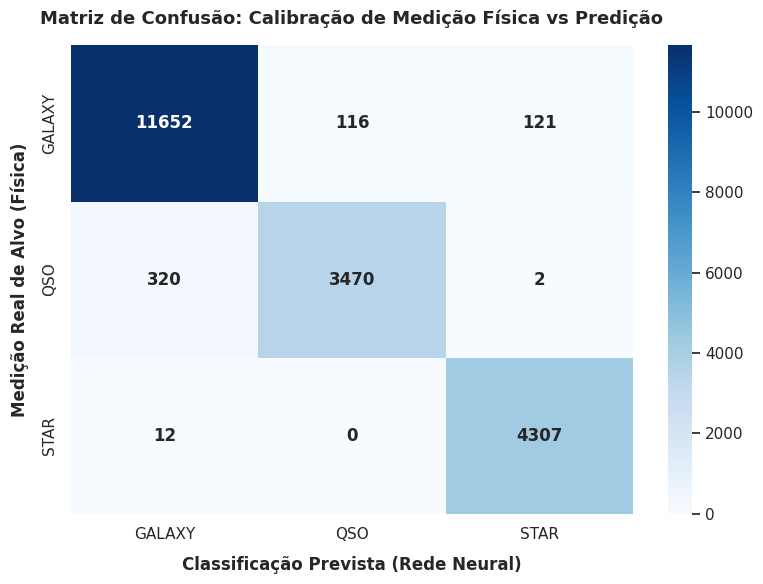

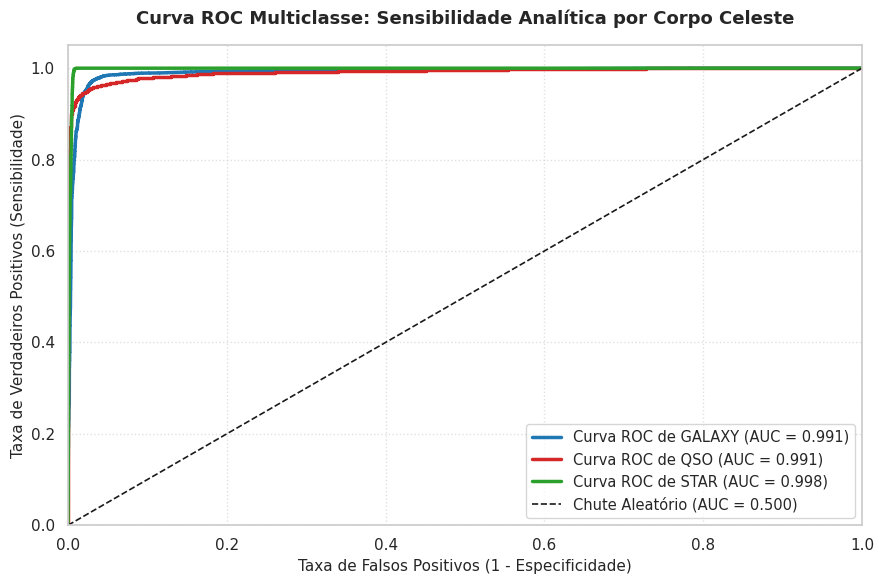


RELATÓRIO TÉCNICO ESTATÍSTICO COMPLEMENTAR:
              precision    recall  f1-score   support

      GALAXY       0.97      0.98      0.98     11889
         QSO       0.97      0.92      0.94      3792
        STAR       0.97      1.00      0.98      4319

    accuracy                           0.97     20000
   macro avg       0.97      0.96      0.97     20000
weighted avg       0.97      0.97      0.97     20000



In [16]:
model_final.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model_final(inputs)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds, all_labels, all_probs = np.array(all_preds), np.array(all_labels), np.array(all_probs)

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names,
            cbar=True, annot_kws={
                'size': 12, 'weight': 'bold'})
plt.xlabel('Classificação Prevista (Rede Neural)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Medição Real de Alvo (Física)', fontsize=12, fontweight='bold', labelpad=10)
plt.title('Matriz de Confusão: Calibração de Medição Física vs Predição', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout(); plt.show()

y_test_bin = label_binarize(all_labels, classes=[0, 1, 2])
plt.figure(figsize=(9, 6))
colors = ['#1f77b4', '#d62728', '#2ca02c']

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2.5, label=f'Curva ROC de {target_names[i]} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Chute Aleatório (AUC = 0.500)')
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (1 - Especificidade)', fontsize=11)
plt.ylabel('Taxa de Verdadeiros Positivos (Sensibilidade)', fontsize=11)
plt.title('Curva ROC Multiclasse: Sensibilidade Analítica por Corpo Celeste', fontsize=13, fontweight='bold', pad=15)
plt.legend(loc="lower right", fontsize=10.5); plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout(); plt.show()

print("\nRELATÓRIO TÉCNICO ESTATÍSTICO COMPLEMENTAR:")
print(classification_report(all_labels, all_preds, target_names=target_names))